In [27]:
import matplotlib.pyplot as plt
import pandas as pd
import gzip

#Fragment Length Frequency


### 1. Reading the .bed.gz file
The .bed.gz file was decompressed using Python’s gzip module and then loaded into a pandas DataFrame. The file follows the standard 6-column BED format, containing the chromosome name, start and end positions, as well as strand information.

In [28]:
col_names = ['chrom', 'start', 'end', 'score', 'strand1', 'strand2']

try: #I made a try catch block here because since query.bed.gz is a large file, it was not uploaded whole on colab and was giving error
    with gzip.open('query.bed.gz', 'rt', errors='replace') as f:
        df = pd.read_csv(f, sep='\t', names=col_names, header=None)
    print(df.head())
except EOFError as e:
    print("File is corrupted or incomplete:", e)

<ipython-input-28-ca527a875f63>:5: DtypeWarning: Columns (3,4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f, sep='\t', names=col_names, header=None)


   chrom     start       end score strand1 strand2
0  chr10  32795245  32795315    70       .       +
1  chr11  95864728  95864770    42       .       +
2  chr16  32027808  32027880    72       .       +
3   chr4  76608451  76608515    64       .       +
4  chr18  45847777  45847816    39       .       -


### 2. Calculate Fragment Lengths
In BED files, the second and third columns are the start and end genomic coordinates of each fragment. Therefore,

Fragment length = end - start

This column will now contain the length in base pairs for each fragment.

In [29]:
df['frag_length'] = df['end'] - df['start']

### 3. Count Occurrences of Each Fragment Length
Using value_counts() [Return a Series containing counts of unique values] and sort_index() [sorts a DataFrame by its index labels (row labels) or column labels], we get the frequency distribution of fragment lengths.

In [30]:
length_counts = df['frag_length'].value_counts()
length_counts = length_counts.sort_index()

### 4. Normalize the Counts
Normalization transforms raw counts into relative frequencies, where the total sum equals 1.0.
This allows for meaningful comparisons between distributions, regardless of sample size.
As a result, the Y-axis represents "Normalized Frequency [A.U.]", with A.U. (arbitrary units) indicating relative values rather than absolute counts.

In [31]:
normalized_counts = length_counts / length_counts.sum() #sum-to-one normalization

### 5. Plot the Distribution
A simple line plot to visualize the distribution.

fragment lengths (X-axis)

normalized frequencies (Y-axis)


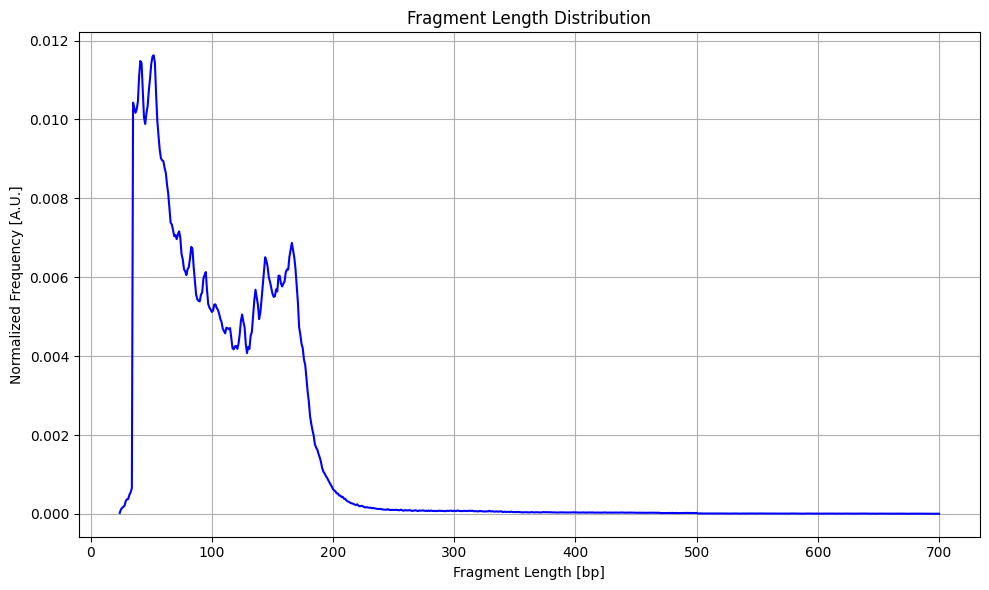

In [32]:
x = normalized_counts.index
y = normalized_counts.values

plt.figure(figsize=(10, 6))
plt.plot(x, y, color='blue')

plt.xlabel("Fragment Length [bp]")
plt.ylabel("Normalized Frequency [A.U.]")
plt.title("Fragment Length Distribution")

plt.grid(True)
plt.tight_layout()

plt.show()

## Summary
We began by computing each DNA fragment’s length from the BED file (end coordinate minus start coordinate). Next, we tallied how many fragments fell into each length category and converted those raw counts into relative frequencies. Lastly, we graphed these normalized frequencies against fragment length, giving us a clear view of how fragment sizes are distributed in the dataset.

# Rescaling Query Data to Match Reference Distribution


### 1. Load the Reference Distribution
The reference distribution is stored in 'reference.hist'. We’ll read this file into a pandas DataFrame, assuming it has two columns: fragment length and its corresponding frequency.

In [33]:
reference_df = pd.read_csv('reference.hist', sep='\t', header=None, names=['frag_length', 'frequency'])
reference_df.head()

,frag_length,frequency
0,24,0.000013
1,25,0.000063
2,26,0.000092
3,27,0.000117
4,28,0.000136


### 2. Calculate Target Fragment Counts
We need to determine how many fragments of each length we need in our query data
to match the reference distribution. This involves scaling the reference frequencies
by the total number of fragments in the query data.

In [34]:
total_queries = len(df)
target_counts = (reference_df['frequency'] * total_queries).astype(int)
target_counts = pd.Series(target_counts.values, index=reference_df['frag_length'])

### 3. Subsample the Query Data
We start by grouping all fragments in our query DataFrame by their length. Then, for each length present in our target_counts dictionary, we either randomly sample the exact number of fragments needed (using a fixed seed for reproducibility) or, if there aren’t enough fragments available, we take them all. Finally, we merge these per-length subsets back into a single DataFrame, subsampled_df, which now reflects the desired fragment-length distribution.

In [35]:
groups = df.groupby('frag_length')

subsampled_fragments = [ #creating a list
    (grp.sample(n=target_counts[length], random_state=42)
     if len(grp) >= target_counts[length] else grp)
    for length, grp in groups
    if length in target_counts
]

subsampled_df = pd.concat(subsampled_fragments, ignore_index=True)

### 4. Verify Rescaling by Plotting
To confirm that our subsampling has matched the target distribution, we’ll overlay the normalized fragment-length curve from the rescaled query data with the original reference distribution. By plotting both on the same axes—with the rescaled query shown as a dashed line and the reference as a solid line—we can visually assess how closely the two distributions align. A strong overlap indicates successful rescaling.

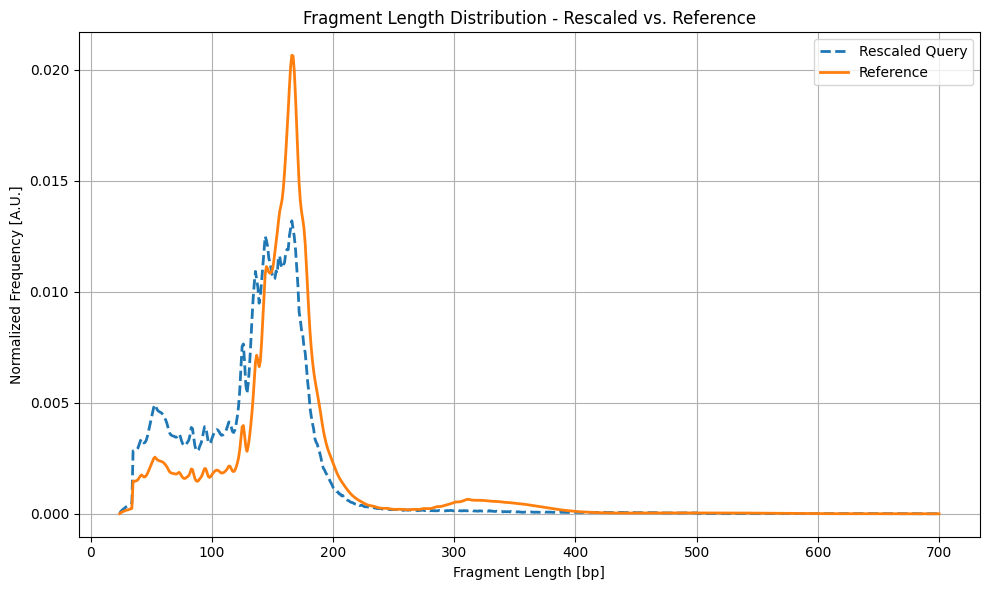

In [36]:
subsampled_length_counts = subsampled_df['frag_length'].value_counts().sort_index()
subsampled_normalized_counts = subsampled_length_counts / subsampled_length_counts.sum() #normalization same as above

x_sub = subsampled_normalized_counts.index
y_sub = subsampled_normalized_counts.values

x_ref = reference_df['frag_length']
y_ref = reference_df['frequency']

plt.figure(figsize=(10, 6))
plt.plot(x_sub, y_sub, linestyle='--', linewidth=2, label='Rescaled Query')
plt.plot(x_ref, y_ref, linewidth=2, label='Reference')

plt.xlabel("Fragment Length [bp]")
plt.ylabel("Normalized Frequency [A.U.]")
plt.title("Fragment Length Distribution - Rescaled vs. Reference")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Summary
We adjusted the query dataset by selectively sampling fragments so that their counts match the target distribution from the reference data. After normalization, the frequency curve of our rescaled query closely aligns with the original reference distribution.